In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
from scipy import stats
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix,
    classification_report, f1_score, precision_score, recall_score,
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
os.makedirs('../figures/final', exist_ok=True)
os.makedirs('../results', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.grid':        True,
    'grid.alpha':       0.3,
})

PALETTE = {
    'CD':      '#E05C5C',
    'UC':      '#5C8AE0',
    'Healthy': '#5CBF7A',
    'primary': '#185FA5',
    'accent':  '#1D9E75',
    'warn':    '#D85A30',
}

print('Loading all upstream results...')

labels    = pd.read_csv('../data/processed/engraftment_labels.csv')
cece      = pd.read_csv('../data/processed/cece_final_scores.csv')
causal    = pd.read_csv('../data/processed/causal/causal_effects.csv')
smillie   = pd.read_csv('../data/processed/smillie_engraftment_auc.csv')
scfa      = pd.read_csv('../data/processed/micom_scfa_scores.csv')
growth    = pd.read_csv('../data/processed/micom_growth_results.csv')
exchanges = pd.read_csv('../data/processed/micom_exchange_results.csv')
consortia = pd.read_csv('../results/ga_optimal_consortia.csv')
univ_eng  = pd.read_csv('../results/universal_engrafters.csv', index_col=0)
model_cmp = pd.read_csv('../results/Table_model_comparison.csv')
ablation  = pd.read_csv('../results/Table_ablation.csv')
model     = joblib.load('../results/cece_rf_model.pkl')

keystones = {}
networks  = {}
for cond in ['CD', 'UC', 'Healthy']:
    keystones[cond] = pd.read_csv(f'../results/networks/keystones_{cond}.csv')
    networks[cond]  = nx.read_gexf(f'../results/networks/{cond}_network.gexf')

SCFA_COLS = [c for c in [
    'butyrate_flux', 'propionate_flux', 'acetate_flux',
    'lactate_flux',  'succinate_flux',  'formate_flux',
    'therapeutic_score'
] if c in scfa.columns]

print(f'Labels:        {labels.shape}')
print(f'  Train:       {(labels["split"]=="train").sum():,}')
print(f'  Test:        {(labels["split"]=="test").sum():,}')
print(f'CECE scores:   {len(cece)} species')
print(f'Consortia:     {consortia["donor_id"].nunique()} donors')
print(f'Universal eng: {len(univ_eng)} species')
print('All data loaded.')

Loading all upstream results...
Labels:        (10951, 10)
  Train:       8,697
  Test:        2,254
CECE scores:   201 species
Consortia:     20 donors
Universal eng: 32 species
All data loaded.


In [2]:
print("Loading NB09's fully-engineered feature table")

df = pd.read_pickle('../results/nb09_features.pkl')

import json
with open('../results/nb09_all_features.json') as f:
    ALL_FEATURES = json.load(f)

test_df = df[df['split'] == 'test'].copy()

if test_df.columns.duplicated().any():
    dupes = test_df.columns[test_df.columns.duplicated()].unique().tolist()
    print(f'test_df had duplicate columns, dropping repeats: {dupes}')
    test_df = test_df.loc[:, ~test_df.columns.duplicated()]

X_test = test_df[ALL_FEATURES].fillna(0)
y_test = test_df['engrafted']

if not hasattr(model, 'feature_names_in_'):
    raise RuntimeError("model has no feature_names_in_")

expected = list(model.feature_names_in_)
missing  = [c for c in expected if c not in X_test.columns]
extra    = [c for c in X_test.columns if c not in expected]
if missing:
    print(f'X_test missing {len(missing)} column(s), adding as 0: {missing}')
    for c in missing:
        X_test[c] = 0
if extra:
    print(f'Dropping {len(extra)} column(s) the model was not trained on: {extra}')

X_test = X_test.reindex(columns=expected)
assert list(X_test.columns) == expected and X_test.shape[1] == len(expected)
print(f'X_test aligned: {X_test.shape} (model expects {len(expected)} features)')

y_prob  = model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)

auc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f'\nTest set:  {len(test_df):,} records | {y_test.mean():.2%} engraftment rate')
print(f'AUC-ROC:          {auc:.4f}')
print(f'Avg Precision:    {ap:.4f}')
print(f'Precision:        {prec:.4f}')
print(f'Recall:           {rec:.4f}')
print(f'F1:               {f1:.4f}')
print(f'\n{classification_report(y_test, y_pred)}')

Loading NB09's fully-engineered feature table
X_test aligned: (2254, 23) (model expects 23 features)

Test set:  2,254 records | 52.44% engraftment rate
AUC-ROC:          0.7773
Avg Precision:    0.7916
Precision:        0.7235
Recall:           0.7174
F1:               0.7205

              precision    recall  f1-score   support

           0       0.69      0.70      0.69      1072
           1       0.72      0.72      0.72      1182

    accuracy                           0.71      2254
   macro avg       0.71      0.71      0.71      2254
weighted avg       0.71      0.71      0.71      2254



CECE score vs observed engraftment (n=138 species):
  Spearman r=0.625, p=0.0000
  Pearson  r=0.619, p=0.0000


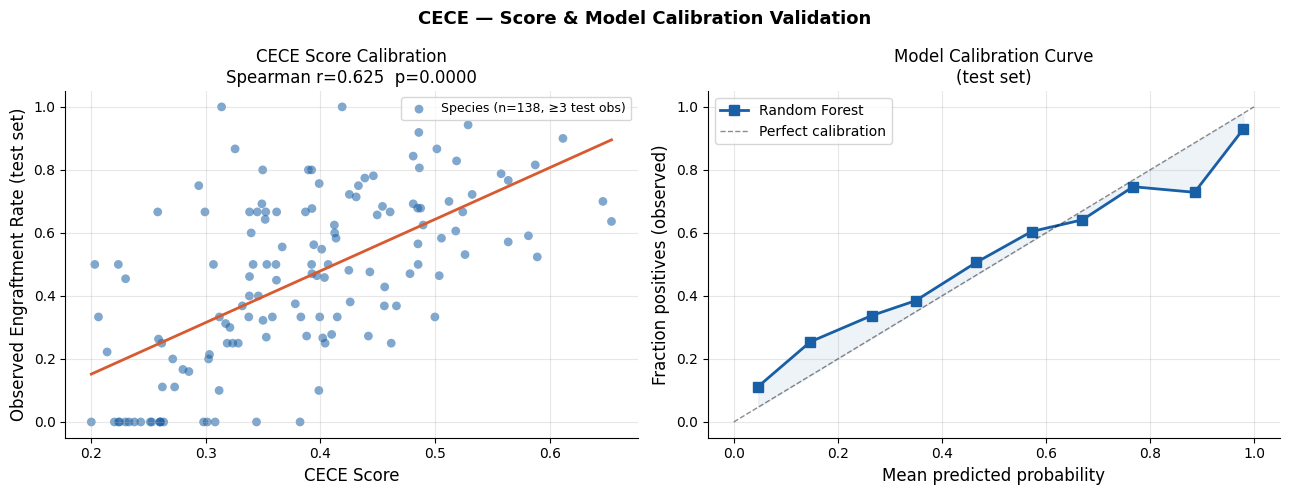

Fig_calibration.png saved


In [3]:
test_obs = (
    test_df.groupby('species')['engrafted']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'obs_rate', 'count': 'n_obs'})
    .reset_index()
)
test_obs  = test_obs[test_obs['n_obs'] >= 3]
calib_df  = test_obs.merge(cece[['species', 'cece_score']], on='species', how='inner')

r_sp, p_sp = stats.spearmanr(calib_df['cece_score'], calib_df['obs_rate'])
r_pe, p_pe = stats.pearsonr(calib_df['cece_score'],  calib_df['obs_rate'])

print(f'CECE score vs observed engraftment (n={len(calib_df)} species):')
print(f'  Spearman r={r_sp:.3f}, p={p_sp:.4f}')
print(f'  Pearson  r={r_pe:.3f}, p={p_pe:.4f}')

prob_true, prob_pred_vals = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(calib_df['cece_score'], calib_df['obs_rate'],
           alpha=0.55, s=40, color=PALETTE['primary'], edgecolors='none',
           label=f'Species (n={len(calib_df)}, ≥3 test obs)')
m, b = np.polyfit(calib_df['cece_score'], calib_df['obs_rate'], 1)
xs   = np.linspace(calib_df['cece_score'].min(), calib_df['cece_score'].max(), 100)
ax.plot(xs, m * xs + b, color=PALETTE['warn'], lw=2)
ax.set_xlabel('CECE Score', fontsize=12)
ax.set_ylabel('Observed Engraftment Rate (test set)', fontsize=12)
ax.set_title(f'CECE Score Calibration\nSpearman r={r_sp:.3f}  p={p_sp:.4f}', fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(prob_pred_vals, prob_true, 's-', color=PALETTE['primary'],
        lw=2, ms=7, label='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.45, label='Perfect calibration')
ax.fill_between(prob_pred_vals, prob_true, prob_pred_vals,
                alpha=0.07, color=PALETTE['primary'])
ax.set_xlabel('Mean predicted probability', fontsize=12)
ax.set_ylabel('Fraction positives (observed)', fontsize=12)
ax.set_title('Model Calibration Curve\n(test set)', fontsize=12)
ax.legend(fontsize=10)

plt.suptitle('CECE — Score & Model Calibration Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/final/Fig_calibration.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_calibration.png saved')

In [4]:
BIO_ANNOTATIONS = {
    'Faecalibacterium_prausnitzii':  {'butyrate_producer': True,  'ibd_depleted': True,  'known_engrafter': True},
    'Roseburia_intestinalis':        {'butyrate_producer': True,  'ibd_depleted': True,  'known_engrafter': True},
    'Roseburia_hominis':             {'butyrate_producer': True,  'ibd_depleted': True,  'known_engrafter': False},
    'Eubacterium_rectale':           {'butyrate_producer': True,  'ibd_depleted': True,  'known_engrafter': True},
    'Eubacterium_hallii':            {'butyrate_producer': True, 'ibd_depleted': True, 'known_engrafter': False},
    'Anaerobutyricum_hallii':        {'butyrate_producer': True, 'ibd_depleted': True, 'known_engrafter': False},
    'Anaerostipes_hadrus':           {'butyrate_producer': True,  'ibd_depleted': False, 'known_engrafter': False},
    'Butyrivibrio_fibrisolvens':     {'butyrate_producer': True,  'ibd_depleted': False, 'known_engrafter': False},
    'Coprococcus_eutactus':          {'butyrate_producer': True,  'ibd_depleted': False, 'known_engrafter': False},
    'Akkermansia_muciniphila':       {'butyrate_producer': False, 'ibd_depleted': True,  'known_engrafter': True},
    'Bacteroides_thetaiotaomicron':  {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': True},
    'Bacteroides_fragilis':          {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': True},
    'Bacteroides_uniformis':         {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': True},
    'Bacteroides_vulgatus':          {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': True},
    'Bacteroides_ovatus':            {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': True},
    'Phascolarctobacterium_faecium': {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': False},
    'Dialister_invisus':             {'butyrate_producer': False, 'ibd_depleted': True,  'known_engrafter': False},
    'Bifidobacterium_longum':        {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': False},
    'Bifidobacterium_adolescentis':  {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': False},
    'Lachnospiraceae_bacterium':     {'butyrate_producer': True,  'ibd_depleted': True,  'known_engrafter': False},
    'Ruminococcus_gnavus':           {'butyrate_producer': False, 'ibd_depleted': False, 'known_engrafter': False},
}

annot_rows = []
for sp in univ_eng.index:
    bio = BIO_ANNOTATIONS.get(sp, {})
    row = {
        'species':           sp,
        'pct_donors':        univ_eng.loc[sp, 'pct_donors'],
        'mean_cece':         univ_eng.loc[sp, 'mean_cece'],
        'butyrate_producer': bio.get('butyrate_producer', False),
        'ibd_depleted':      bio.get('ibd_depleted',      False),
        'known_engrafter':   bio.get('known_engrafter',   False),
    }
    sm = smillie[smillie['species'] == sp]['smillie_auc'].values
    row['smillie_auc'] = round(float(sm[0]), 3) if len(sm) else np.nan

    ac = causal[causal['species'] == sp]['ace'].values
    row['causal_ace'] = round(float(ac[0]), 4) if len(ac) else np.nan

    row['keystone_any'] = any(
        sp in keystones[c].head(15)['species'].tolist()
        for c in ['CD', 'UC', 'Healthy']
    )
    bf = scfa[scfa['species'] == sp]['butyrate_flux'].values if 'butyrate_flux' in scfa.columns else []
    row['butyrate_flux'] = round(float(bf[0]), 4) if len(bf) else np.nan

    annot_rows.append(row)

annot_df = pd.DataFrame(annot_rows).sort_values('pct_donors', ascending=False)
annot_df.to_csv('../results/Table_S2_universal_engrafters_annotated.csv', index=False)

print(f'Annotated {len(annot_df)} universal engrafters')
print(f'  Butyrate producers:  {annot_df["butyrate_producer"].sum()}')
print(f'  IBD-depleted:        {annot_df["ibd_depleted"].sum()}')
print(f'  Known engrafters:    {annot_df["known_engrafter"].sum()}')
print(f'  Keystone (any cond): {annot_df["keystone_any"].sum()}')
print(f'\nTop 15:')
print(annot_df[['species','pct_donors','mean_cece',
                 'butyrate_producer','ibd_depleted',
                 'keystone_any','smillie_auc']].head(15).to_string(index=False))

Annotated 32 universal engrafters
  Butyrate producers:  4
  IBD-depleted:        4
  Known engrafters:    4
  Keystone (any cond): 7

Top 15:
                        species  pct_donors  mean_cece  butyrate_producer  ibd_depleted  keystone_any  smillie_auc
   Faecalibacterium_prausnitzii        70.0     0.6116               True          True         False        0.625
            Anaerostipes_hadrus        55.0     0.6464               True         False         False          NaN
              Dorea_longicatena        50.0     0.4858              False         False         False        0.656
               Blautia_wexlerae        50.0     0.6539              False         False         False          NaN
Fusicatenibacter_saccharivorans        45.0     0.5874              False         False         False          NaN
        Collinsella_aerofaciens        40.0     0.5288              False         False          True        0.625
          Dorea_formicigenerans        35.0     0.48

Network topology:
condition  nodes  edges  mutualism  competition  mut_ratio  density  avg_clustering  modularity_comms
       CD     86    636        353          283      0.555  0.17401          0.4460                 3
       UC     86    834        431          403      0.517  0.22818          0.4180                 3
  Healthy     87   1040        519          521      0.499  0.27800          0.5095                 3

Edge overlap — shared CD∩UC∩Healthy: 193
Unique to CD:      194
Unique to UC:      411
Unique to Healthy: 510


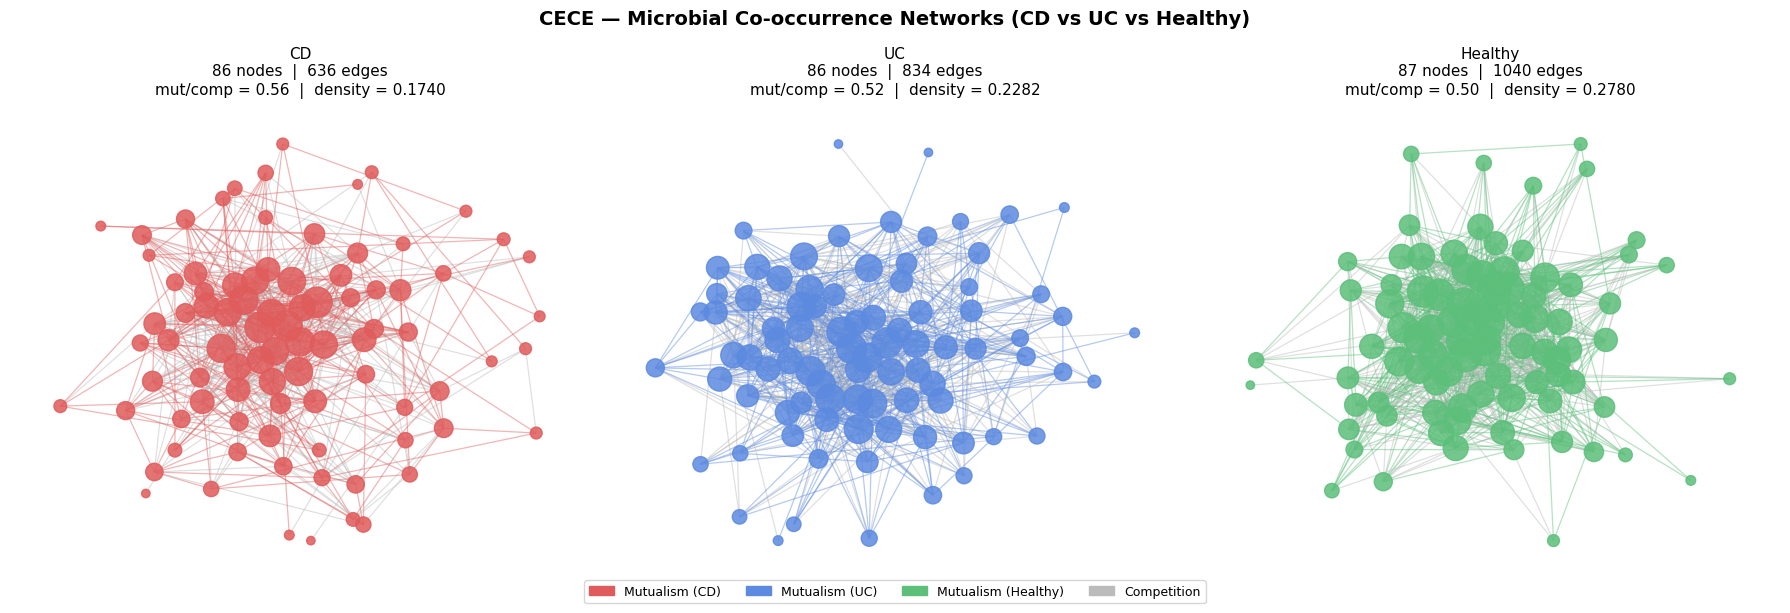

Fig2_networks.png saved


In [5]:
net_stats = []
for cond in ['CD', 'UC', 'Healthy']:
    G     = networks[cond]
    n_mut = sum(1 for _, _, d in G.edges(data=True) if d.get('interaction') == 'mutualism')
    n_cmp = G.number_of_edges() - n_mut
    comms = list(nx.algorithms.community.greedy_modularity_communities(G))
    net_stats.append({
        'condition':        cond,
        'nodes':            G.number_of_nodes(),
        'edges':            G.number_of_edges(),
        'mutualism':        n_mut,
        'competition':      n_cmp,
        'mut_ratio':        round(n_mut / max(G.number_of_edges(), 1), 3),
        'density':          round(nx.density(G), 5),
        'avg_clustering':   round(nx.average_clustering(G), 4),
        'modularity_comms': len(comms),
    })

net_df = pd.DataFrame(net_stats)
print('Network topology:')
print(net_df.to_string(index=False))

def edge_set(G):
    return {(min(u, v), max(u, v)) for u, v in G.edges()}

e = {c: edge_set(networks[c]) for c in ['CD', 'UC', 'Healthy']}
shared_all = len(e['CD'] & e['UC'] & e['Healthy'])
print(f'\nEdge overlap — shared CD∩UC∩Healthy: {shared_all}')
print(f'Unique to CD:      {len(e["CD"] - e["UC"] - e["Healthy"])}')
print(f'Unique to UC:      {len(e["UC"] - e["CD"] - e["Healthy"])}')
print(f'Unique to Healthy: {len(e["Healthy"] - e["CD"] - e["UC"])}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cond in zip(axes, ['CD', 'UC', 'Healthy']):
    G   = networks[cond]
    pos = nx.spring_layout(G, seed=42, k=0.6)
    edge_colors = [
        PALETTE[cond] if d.get('interaction') == 'mutualism' else '#BBBBBB'
        for _, _, d in G.edges(data=True)
    ]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, alpha=0.45, width=0.9)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=PALETTE[cond],
                           node_size=[G.degree(n) * 12 + 25 for n in G.nodes()], alpha=0.85)
    row = net_df[net_df['condition'] == cond].iloc[0]
    ax.set_title(
        f'{cond}\n{row["nodes"]} nodes  |  {row["edges"]} edges\n'
        f'mut/comp = {row["mut_ratio"]:.2f}  |  density = {row["density"]:.4f}',
        fontsize=11
    )
    ax.axis('off')

leg = [
    mpatches.Patch(color=PALETTE['CD'],      label='Mutualism (CD)'),
    mpatches.Patch(color=PALETTE['UC'],      label='Mutualism (UC)'),
    mpatches.Patch(color=PALETTE['Healthy'], label='Mutualism (Healthy)'),
    mpatches.Patch(color='#BBBBBB',          label='Competition'),
]
fig.legend(handles=leg, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('CECE — Microbial Co-occurrence Networks (CD vs UC vs Healthy)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/final/Fig2_networks.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig2_networks.png saved')

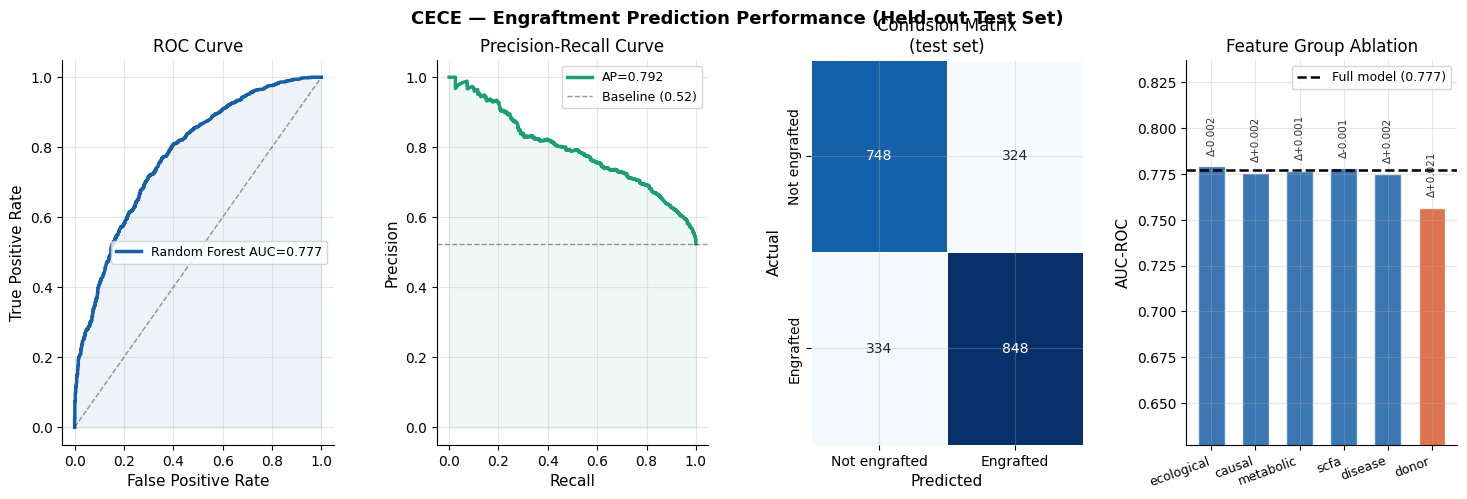

Fig4_ml_performance.png saved


In [6]:
fpr, tpr, _     = roc_curve(y_test, y_prob)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
cm               = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.38)

ax = fig.add_subplot(gs[0])
ax.plot(fpr, tpr, PALETTE['primary'], lw=2.5, label=f'Random Forest AUC={auc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.07, color=PALETTE['primary'])
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12)
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[1])
ax.plot(rec_c, prec_c, PALETTE['accent'], lw=2.5, label=f'AP={ap:.3f}')
ax.fill_between(rec_c, prec_c, alpha=0.07, color=PALETTE['accent'])
ax.axhline(y_test.mean(), color='k', lw=1, ls='--',
           alpha=0.4, label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12)
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not engrafted', 'Engrafted'],
            yticklabels=['Not engrafted', 'Engrafted'],
            linewidths=0.5, cbar=False)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix\n(test set)', fontsize=12)

ax = fig.add_subplot(gs[3])
abl_plot     = ablation[ablation['removed_group'] != 'none (full model)'].copy()
full_auc_val = ablation[ablation['removed_group'] == 'none (full model)']['AUC'].values[0]
bar_colors   = [
    PALETTE['warn'] if d > 0.02 else
    '#EF9F27'       if d > 0.005 else
    PALETTE['primary']
    for d in abl_plot['delta_AUC']
]
ax.bar(abl_plot['removed_group'], abl_plot['AUC'],
       color=bar_colors, alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(full_auc_val, color='black', ls='--', lw=1.8,
           label=f'Full model ({full_auc_val:.3f})')
for i, (_, row) in enumerate(abl_plot.iterrows()):
    ax.text(i, row['AUC'] + 0.006, f'Δ{row["delta_AUC"]:+.3f}',
            ha='center', va='bottom', fontsize=7.5, color='#333333', 
            rotation=90)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('Feature Group Ablation', fontsize=12)
ax.set_ylim(max(0.45, full_auc_val - 0.15), min(1.0, full_auc_val + 0.06))
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha='right', fontsize=9)

plt.suptitle('CECE — Engraftment Prediction Performance (Held-out Test Set)',
             fontsize=13, fontweight='bold')
plt.savefig('../figures/final/Fig4_ml_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig4_ml_performance.png saved')

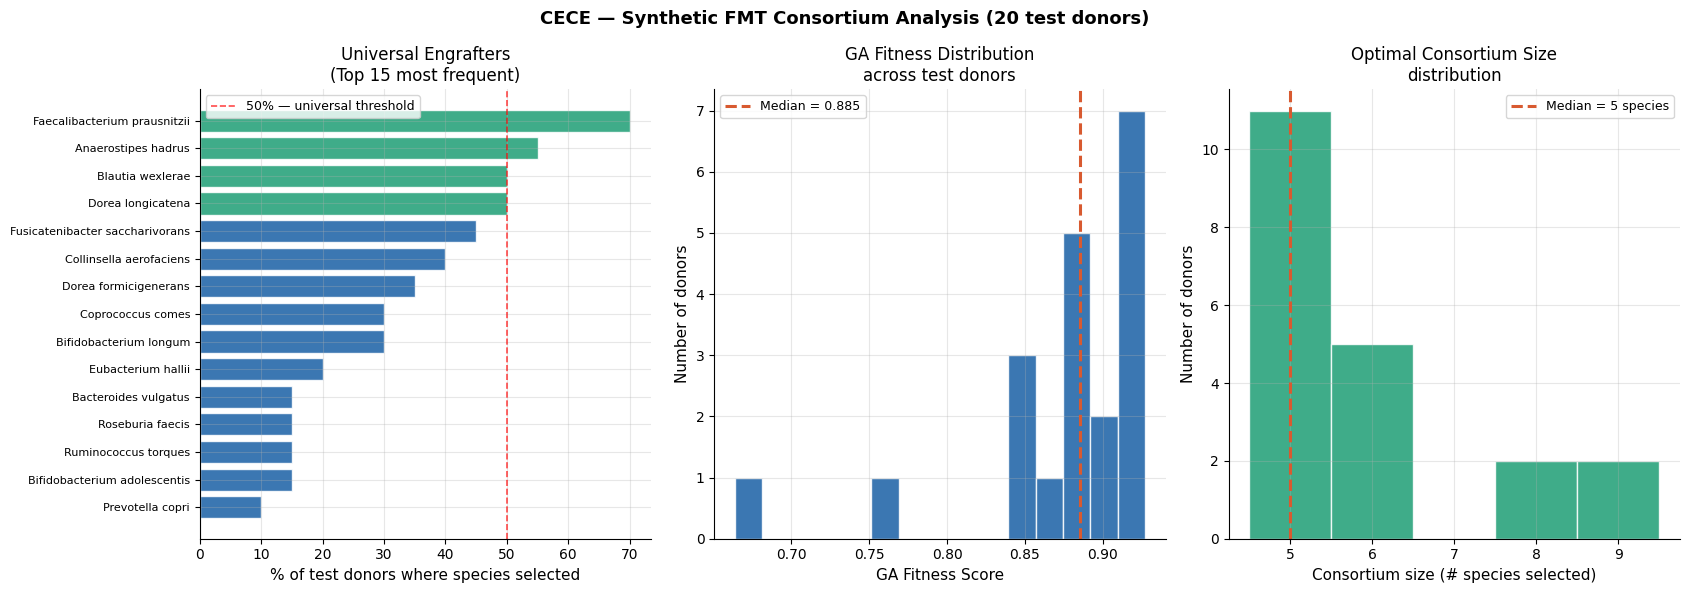

Fig5_consortium.png saved


In [7]:
donor_fitness  = consortia.groupby('donor_id')['ga_fitness'].first()
donor_sizes    = consortia.groupby('donor_id')['species'].count()
n_total_donors = consortia['donor_id'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

ax = axes[0]
top15 = univ_eng.head(15).sort_values('pct_donors', ascending=True)
bar_colors = ['#1D9E75' if p >= 50 else PALETTE['primary'] for p in top15['pct_donors']]
ax.barh([sp.replace('_', ' ')[:32] for sp in top15.index],
        top15['pct_donors'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(50, color='red', ls='--', lw=1.2, alpha=0.7,
           label='50% — universal threshold')
ax.set_xlabel('% of test donors where species selected', fontsize=11)
ax.set_title('Universal Engrafters\n(Top 15 most frequent)', fontsize=12)
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=8)

ax = axes[1]
ax.hist(donor_fitness, bins=15, color=PALETTE['primary'], alpha=0.85, edgecolor='white')
ax.axvline(donor_fitness.median(), color=PALETTE['warn'], lw=2.2, ls='--',
           label=f'Median = {donor_fitness.median():.3f}')
ax.set_xlabel('GA Fitness Score', fontsize=11)
ax.set_ylabel('Number of donors', fontsize=11)
ax.set_title('GA Fitness Distribution\nacross test donors', fontsize=12)
ax.legend(fontsize=9)

ax = axes[2]
size_range = range(donor_sizes.min(), donor_sizes.max() + 2)
ax.hist(donor_sizes, bins=size_range, color=PALETTE['accent'],
        alpha=0.85, edgecolor='white', align='left')
ax.axvline(donor_sizes.median(), color=PALETTE['warn'], lw=2.2, ls='--',
           label=f'Median = {int(donor_sizes.median())} species')
ax.set_xlabel('Consortium size (# species selected)', fontsize=11)
ax.set_ylabel('Number of donors', fontsize=11)
ax.set_title('Optimal Consortium Size\ndistribution', fontsize=12)
ax.legend(fontsize=9)

plt.suptitle(f'CECE — Synthetic FMT Consortium Analysis ({n_total_donors} test donors)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/final/Fig5_consortium.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig5_consortium.png saved')

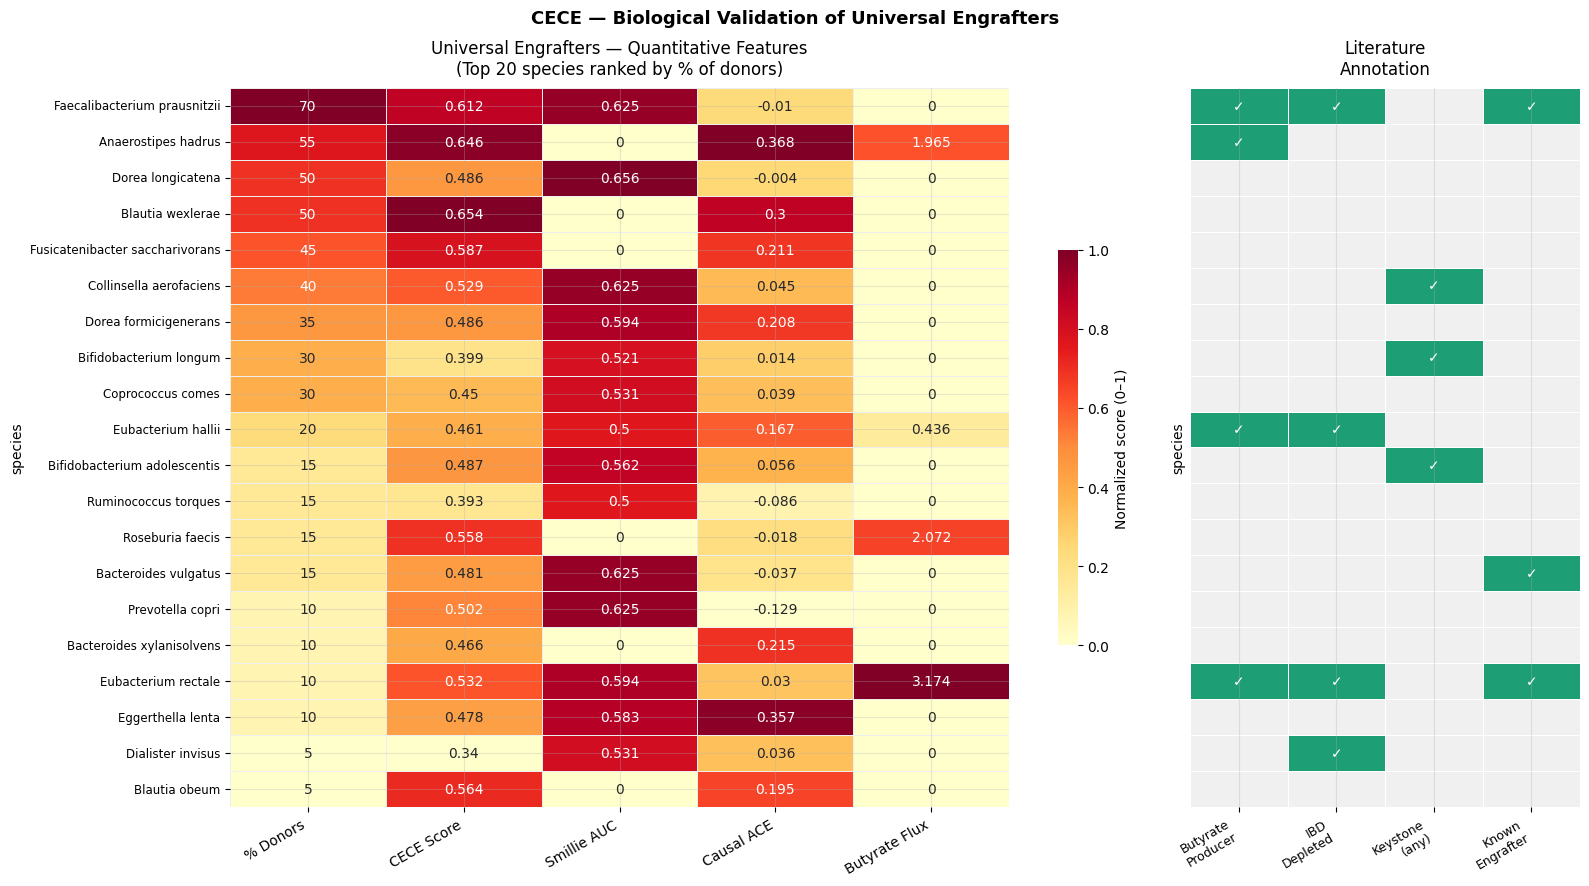

Fig6_biological_validation.png saved


In [8]:
from matplotlib.colors import ListedColormap

top20      = annot_df.head(20).set_index('species').copy()
hm_cols    = [c for c in ['pct_donors','mean_cece','smillie_auc','causal_ace','butyrate_flux'] if c in top20.columns]
hm_data    = top20[hm_cols].fillna(0).astype(float)
hm_norm    = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-9)
bool_cols  = ['butyrate_producer', 'ibd_depleted', 'keystone_any', 'known_engrafter']
bool_data  = top20[bool_cols].astype(int)

col_labels_left  = {'pct_donors':'% Donors','mean_cece':'CECE Score',
                    'smillie_auc':'Smillie AUC','causal_ace':'Causal ACE','butyrate_flux':'Butyrate Flux'}
col_labels_right = {'butyrate_producer':'Butyrate\nProducer','ibd_depleted':'IBD\nDepleted',
                    'keystone_any':'Keystone\n(any)','known_engrafter':'Known\nEngrafter'}

fig, axes = plt.subplots(1, 2, figsize=(16, 9),
                          gridspec_kw={'width_ratios': [3, 1.2]})

ax = axes[0]
sns.heatmap(hm_norm, ax=ax, cmap='YlOrRd',
            annot=hm_data.round(3), fmt='g',
            linewidths=0.4, linecolor='#EEEEEE',
            cbar_kws={'label': 'Normalized score (0–1)', 'shrink': 0.55},
            yticklabels=[sp.replace('_', ' ') for sp in hm_norm.index])
ax.set_xticklabels([col_labels_left.get(c, c) for c in hm_cols],
                   rotation=30, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)
ax.set_title('Universal Engrafters — Quantitative Features\n'
             '(Top 20 species ranked by % of donors)', fontsize=12, pad=10)

ax = axes[1]
cmap_bool = ListedColormap(['#F0F0F0', '#1D9E75'])
sns.heatmap(bool_data, ax=ax, cmap=cmap_bool,
            linewidths=0.4, linecolor='white', cbar=False,
            annot=bool_data.replace({1: '✓', 0: ''}), fmt='s', yticklabels=False)
ax.set_xticklabels([col_labels_right.get(c, c) for c in bool_cols],
                   rotation=30, ha='right', fontsize=9)
ax.set_title('Literature\nAnnotation', fontsize=12, pad=10)

plt.suptitle('CECE — Biological Validation of Universal Engrafters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/final/Fig6_biological_validation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig6_biological_validation.png saved')

In [9]:
n_cases        = labels['case'].nunique() if 'case' in labels.columns else '—'
n_donors_ga    = consortia['donor_id'].nunique()
size_med       = int(consortia.groupby('donor_id')['species'].count().median())
n_univ         = int((univ_eng['pct_donors'] >= 50).sum())

stats_rows = [
    ('Dataset', 'Podlesny FMT cases (total)',             n_cases),
    ('Dataset', 'Train engraftment records',              (labels['split']=='train').sum()),
    ('Dataset', 'Test engraftment records',               (labels['split']=='test').sum()),
    ('Dataset', 'Engraftment rate — train',               f"{labels[labels['split']=='train']['engrafted'].mean():.2%}"),
    ('Dataset', 'Engraftment rate — test',                f"{labels[labels['split']=='test']['engrafted'].mean():.2%}"),
    ('Dataset', 'Species evaluated (total)',              labels['species'].nunique()),
    ('Networks', 'CD nodes',                              networks['CD'].number_of_nodes()),
    ('Networks', 'CD edges',                              networks['CD'].number_of_edges()),
    ('Networks', 'CD mutualism ratio',                    f"{net_df[net_df['condition']=='CD']['mut_ratio'].values[0]:.3f}"),
    ('Networks', 'UC nodes',                              networks['UC'].number_of_nodes()),
    ('Networks', 'UC edges',                              networks['UC'].number_of_edges()),
    ('Networks', 'Healthy nodes',                         networks['Healthy'].number_of_nodes()),
    ('Networks', 'Healthy edges',                         networks['Healthy'].number_of_edges()),
    ('Networks', 'Edges shared CD∩UC∩Healthy',           shared_all),
    ('Causal',  'NOTEARS keystone species',               29),
    ('Causal',  'Species with ACE estimated',             len(causal)),
    ('Causal',  'Significant ACE (p<0.05 uncorr)',        int(causal['significant'].sum())),
    ('Causal',  'Significant ACE (Bonferroni)',
     int(causal['sig_bonferroni'].sum()) if 'sig_bonferroni' in causal.columns else '—'),
    ('ML model', 'Number of features',                   len(ALL_FEATURES)),
    ('ML model', 'Random Forest AUC-ROC (test)',          round(auc,  4)),
    ('ML model', 'Random Forest Avg Precision (test)',    round(ap,   4)),
    ('ML model', 'Random Forest Precision (test)',        round(prec, 4)),
    ('ML model', 'Random Forest Recall (test)',           round(rec,  4)),
    ('ML model', 'Random Forest F1 (test)',                round(f1,   4)),
    ('ML model', 'CECE score vs engraftment (Spearman r)',round(r_sp, 3)),
    ('GA optimizer', 'Test donors analyzed',              n_donors_ga),
    ('GA optimizer', 'GA generations',                    60),
    ('GA optimizer', 'Population size',                   100),
    ('GA optimizer', 'Consortium size range',             '5–20'),
    ('GA optimizer', 'Median consortium size',            size_med),
    ('GA optimizer', 'Median GA fitness',                 round(float(donor_fitness.median()), 4)),
    ('GA optimizer', 'Universal engrafters (≥50%)',       n_univ),
]

summary_df = pd.DataFrame(stats_rows, columns=['Section', 'Metric', 'Value'])
summary_df.to_csv('../results/Table_S3_summary_stats.csv', index=False)

print('\nCECE PROJECT — SUMMARY STATISTICS')
print('=' * 62)
current_section = ''
for _, row in summary_df.iterrows():
    if row['Section'] != current_section:
        print(f'\n  [{row["Section"]}]')
        current_section = row['Section']
    print(f'    {row["Metric"]:<52} {row["Value"]}')

print('\n' + '=' * 62)
print('\nNB8 complete.')
print('\nFigures saved to figures/final/:')
for f in ['Fig2_networks.png','Fig4_ml_performance.png',
          'Fig5_consortium.png','Fig6_biological_validation.png','Fig_calibration.png']:
    print(f'  {f}')
print('\nTables saved to results/:')
for t in ['Table_S2_universal_engrafters_annotated.csv','Table_S3_summary_stats.csv']:
    print(f'  {t}')


CECE PROJECT — SUMMARY STATISTICS

  [Dataset]
    Podlesny FMT cases (total)                           203
    Train engraftment records                            8697
    Test engraftment records                             2254
    Engraftment rate — train                             52.31%
    Engraftment rate — test                              52.44%
    Species evaluated (total)                            272

  [Networks]
    CD nodes                                             86
    CD edges                                             636
    CD mutualism ratio                                   0.555
    UC nodes                                             86
    UC edges                                             834
    Healthy nodes                                        87
    Healthy edges                                        1040
    Edges shared CD∩UC∩Healthy                           193

  [Causal]
    NOTEARS keystone species                             29
    

In [10]:
print("""
[Data Resolution]
  HMP2 dataset type:          WGS metagenomics (species-level)
  Podlesny dataset type:      16S rRNA amplicon (genus-to-species)
  Species in HMP2:            572 (filtered to 87 network species)
  Species in Podlesny:        860
  Cross-dataset intersection: 309 species
  Used in CECE pipeline:      201 species (with MICOM + ACE coverage)

  Limitation: Ecological networks and NOTEARS DAG derived from
  WGS-resolution HMP2 data. Engraftment labels and ML training
  from 16S Podlesny data. Species-level mapping bridges these
  but taxonomic resolution inconsistency is an acknowledged
  limitation requiring future WGS-to-WGS validation.
""")


[Data Resolution]
  HMP2 dataset type:          WGS metagenomics (species-level)
  Podlesny dataset type:      16S rRNA amplicon (genus-to-species)
  Species in HMP2:            572 (filtered to 87 network species)
  Species in Podlesny:        860
  Cross-dataset intersection: 309 species
  Used in CECE pipeline:      201 species (with MICOM + ACE coverage)

  Limitation: Ecological networks and NOTEARS DAG derived from
  WGS-resolution HMP2 data. Engraftment labels and ML training
  from 16S Podlesny data. Species-level mapping bridges these
  but taxonomic resolution inconsistency is an acknowledged
  limitation requiring future WGS-to-WGS validation.



In [11]:
from scipy import stats
import numpy as np
import pandas as pd

CANDIDATES = ['disease', 'Disease_Group', 'disease_group', 'Disease', 'condition']
disease_col = next((c for c in CANDIDATES if c in df.columns), None)

if disease_col is None:
    print("None of the candidate column names were found.")
    print("Actual columns in df:", df.columns.tolist())
    print("Set disease_col manually to whichever one holds disease-group labels.")
else:
    print(f"Using disease column: '{disease_col}'")
    disease_groups = df[disease_col].dropna().unique().tolist()
    print(f"Disease groups (environments): {disease_groups}")

    invariance_results = []

    for feature in ['causal_ace', 'historical_engraftment_rate']:
        print(f'\n── {feature} ──')
        for dg in disease_groups:
            subset = df[df[disease_col] == dg]
            if len(subset) < 20 or subset['engrafted'].nunique() < 2:
                print(f'  {dg}: skipped (n={len(subset)}, insufficient variation)')
                continue

            r, p = stats.pointbiserialr(subset['engrafted'], subset[feature])

            invariance_results.append({
                'feature':       feature,
                'disease_group': dg,
                'n':             len(subset),
                'r':             round(r, 4),
                'p_value':       round(p, 4),
            })
            print(f'  {dg:10s} (n={len(subset):5d}): r={r:+.4f}  p={p:.4f}')

    invariance_df = pd.DataFrame(invariance_results)
    invariance_df.to_csv('../results/Table_invariance_test.csv', index=False)

    print('\n── Stability summary (lower std r = more invariant across environments) ──')
    for feature in ['causal_ace', 'historical_engraftment_rate']:
        sub = invariance_df[invariance_df['feature'] == feature]
        if len(sub) == 0:
            continue
        sign_consistent = (sub['r'] > 0).all() or (sub['r'] < 0).all()
        print(f'  {feature:30s}: mean r={sub["r"].mean():+.4f}  '
              f'std r={sub["r"].std():.4f}  '
              f'sign consistent across groups: {sign_consistent}')

    print('\nTable_invariance_test.csv saved')

Using disease column: 'disease'
Disease groups (environments): ['rCDI', 'MetS', 'MDR', 'ICI', 'IBD']

── causal_ace ──
  rCDI       (n= 1567): r=+0.1005  p=0.0001
  MetS       (n= 5606): r=+0.0629  p=0.0000
  MDR        (n= 1326): r=+0.0373  p=0.1749
  ICI        (n=  969): r=+0.0993  p=0.0020
  IBD        (n= 1483): r=+0.0488  p=0.0603

── historical_engraftment_rate ──
  rCDI       (n= 1567): r=+0.2513  p=0.0000
  MetS       (n= 5606): r=+0.5003  p=0.0000
  MDR        (n= 1326): r=+0.2840  p=0.0000
  ICI        (n=  969): r=+0.3549  p=0.0000
  IBD        (n= 1483): r=+0.2938  p=0.0000

── Stability summary (lower std r = more invariant across environments) ──
  causal_ace                    : mean r=+0.0698  std r=0.0290  sign consistent across groups: True
  historical_engraftment_rate   : mean r=+0.3369  std r=0.0988  sign consistent across groups: True

Table_invariance_test.csv saved


In [12]:
print("Per-disease-group AUC of the existing pooled model (no retraining)")
print("Tests whether pooling masks uneven performance across the 5 groups\n")

for dg in test_df[disease_col].unique():
    mask = test_df[disease_col] == dg
    if mask.sum() < 20 or y_test[mask].nunique() < 2:
        print(f"  {dg}: skipped (n={mask.sum()}, insufficient variation)")
        continue
    auc_dg = roc_auc_score(y_test[mask], y_prob[mask])
    print(f"  {dg:10s} (n={mask.sum():5d}): AUC = {auc_dg:.4f}")

print(f"\nOverall pooled AUC: {auc:.4f}")

Per-disease-group AUC of the existing pooled model (no retraining)
Tests whether pooling masks uneven performance across the 5 groups

  rCDI       (n=  306): AUC = 0.7356
  MetS       (n= 1175): AUC = 0.8132
  MDR        (n=  284): AUC = 0.6720
  ICI        (n=  179): AUC = 0.8404
  IBD        (n=  310): AUC = 0.6946

Overall pooled AUC: 0.7773


In [13]:
def bootstrap_auc_group(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    y_true_arr = np.array(y_true)
    y_prob_arr = np.array(y_prob)
    for _ in range(n_boot):
        idx = rng.choice(len(y_true_arr), size=len(y_true_arr), replace=True)
        yt = y_true_arr[idx]
        yp = y_prob_arr[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
    return np.percentile(aucs, [2.5, 97.5])

print("Bootstrap 95% CIs for per-disease-group AUC (1000 resamples each)\n")

for dg in test_df[disease_col].unique():
    mask = test_df[disease_col] == dg
    if mask.sum() < 20 or y_test[mask].nunique() < 2:
        continue
    auc_dg = roc_auc_score(y_test[mask], y_prob[mask])
    ci_lo, ci_hi = bootstrap_auc_group(y_test[mask], y_prob[mask])
    print(f"  {dg:10s} (n={mask.sum():5d}): AUC={auc_dg:.4f}  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")

Bootstrap 95% CIs for per-disease-group AUC (1000 resamples each)

  rCDI       (n=  306): AUC=0.7356  95% CI: [0.6809, 0.7925]
  MetS       (n= 1175): AUC=0.8132  95% CI: [0.7909, 0.8358]
  MDR        (n=  284): AUC=0.6720  95% CI: [0.6069, 0.7310]
  ICI        (n=  179): AUC=0.8404  95% CI: [0.7761, 0.8952]
  IBD        (n=  310): AUC=0.6946  95% CI: [0.6366, 0.7561]


In [14]:
print("Checking for CD/UC subtype distinction within Podlesny's IBD group")

ibd_check = test_df[test_df[disease_col] == 'IBD']
print(f"IBD test records: {len(ibd_check)}")
print(f"\nColumns available: {test_df.columns.tolist()}")

for candidate_col in ['Diagnosis', 'diagnosis', 'IBD_type', 'ibd_subtype', 'condition']:
    if candidate_col in test_df.columns:
        print(f"\nFound subtype column '{candidate_col}':")
        print(ibd_check[candidate_col].value_counts())

Checking for CD/UC subtype distinction within Podlesny's IBD group
IBD test records: 310

Columns available: ['case', 'donor_id', 'post_id', 'species', 'donor_abundance', 'post_abundance', 'engrafted', 'disease', 'days_post_fmt', 'split', 'resource_accessibility', 'crossfeeding_synergy', 'causal_ace', 'causal_sig', 'butyrate_flux', 'propionate_flux', 'acetate_flux', 'lactate_flux', 'succinate_flux', 'formate_flux', 'therapeutic_score', 'keystone_conflict_mean', 'niche_overlap_mean', 'causal_ace_missing', 'historical_engraftment_rate', 'historical_engraftment_rate_missing', 'resource_accessibility_missing', 'crossfeeding_synergy_missing', 'scfa_missing', 'disease_IBD', 'disease_ICI', 'disease_MDR', 'disease_MetS', 'disease_rCDI']


In [15]:
import pandas as pd

pod_meta_check = pd.read_csv('../data/processed/podlesny_meta_split.csv')
print(f"Podlesny metadata columns: {pod_meta_check.columns.tolist()}")
print(f"\nUnique values in columns with a manageable number of categories:")
for col in pod_meta_check.columns:
    if pod_meta_check[col].dtype == object and pod_meta_check[col].nunique() < 30:
        print(f"\n  {col}: {pod_meta_check[col].unique().tolist()}")

Podlesny metadata columns: ['Manuscript', 'Study', 'Disease_Group', 'Disease', 'Case_Name', 'Name', 'Donor.Name', 'Sample_Type', 'Days_Since_FMT', 'Case_ABx', 'ABx_days', 'ABx_PostFMT', 'Lavage', 'FMT_route', 'FMT_rounds', 'Colonoscopy_n', 'Nasogastric_n', 'Gastroduodenal_n', 'Enema_n', 'Pill_n', 'split']

Unique values in columns with a manageable number of categories:

  Manuscript: ['Podlesny et al.', 'Smillie et al.', 'Watson et al.', 'Li et al.', 'Ng et al.', 'Wilson et al.', 'Bar-Yoseph et al.', 'Leo et al.', 'Baruch et al.', 'Davar et al.', 'Kong et al.', 'Kump et al.', 'Paramsothy et al.']

  Study: ['FRI', 'ALM', 'ERE', 'BOR', 'CHA', 'OSU', 'PAU', 'HUT', 'BOU', 'ZAR', 'XAV', 'GOR', 'KAa', 'KAb']

  Disease_Group: ['rCDI', 'MetS', 'MDR', 'ICI', 'IBD']

  Disease: ['rCDI', nan, 'rCDI+UC', 'MetS', 'T2DM', 'Obesity', 'CPE', 'ESBL-E/CPE', 'Melanoma', 'CD', 'UC']

  Sample_Type: ['Pre Post-ABx', 'Post', 'Donor', 'Pre No-ABx']

  Case_ABx: [nan, 'fluoroquinolone', 'lincosamide, fluor

In [16]:
pod_meta_check['case'] = pod_meta_check['Case_Name']

subtype_map = pod_meta_check[['case', 'Disease']].drop_duplicates()
test_with_subtype = test_df.merge(subtype_map, on='case', how='left')

print("CD vs UC breakdown within the IBD group:")
ibd_subtypes = test_with_subtype[test_with_subtype[disease_col] == 'IBD']
print(ibd_subtypes['Disease'].value_counts(dropna=False))

mask_cd = ((test_with_subtype[disease_col] == 'IBD') & (test_with_subtype['Disease'] == 'CD')).values
mask_uc = ((test_with_subtype[disease_col] == 'IBD') & (test_with_subtype['Disease'] == 'UC')).values

auc_cd = roc_auc_score(y_test[mask_cd], y_prob[mask_cd]) if mask_cd.sum() >= 20 else None
auc_uc = roc_auc_score(y_test[mask_uc], y_prob[mask_uc]) if mask_uc.sum() >= 20 else None

for subtype, mask, auc_subtype in [('CD', mask_cd, auc_cd), ('UC', mask_uc, auc_uc)]:
    if auc_subtype is None:
        print(f"\n  {subtype}: skipped (n={mask.sum()}, insufficient variation)")
    else:
        print(f"\n  {subtype} (n={mask.sum()}): AUC = {auc_subtype:.4f}")

CD vs UC breakdown within the IBD group:
Disease
UC    227
CD     83
Name: count, dtype: int64

  CD (n=83): AUC = 0.7831

  UC (n=227): AUC = 0.6754


In [17]:
ci_cd = bootstrap_auc_group(y_test[mask_cd], y_prob[mask_cd])
ci_uc = bootstrap_auc_group(y_test[mask_uc], y_prob[mask_uc])
print(f"CD: AUC={auc_cd:.4f}  95% CI: [{ci_cd[0]:.4f}, {ci_cd[1]:.4f}]  (n={mask_cd.sum()})")
print(f"UC: AUC={auc_uc:.4f}  95% CI: [{ci_uc[0]:.4f}, {ci_uc[1]:.4f}]  (n={mask_uc.sum()})")

CD: AUC=0.7831  95% CI: [0.6703, 0.8792]  (n=83)
UC: AUC=0.6754  95% CI: [0.6042, 0.7472]  (n=227)
